<a href="https://colab.research.google.com/github/mrdantzig/nlp-bible-code/blob/master/08%EC%9E%A5_%EA%B0%9C%EC%B2%B4%EB%AA%85%EC%9D%B8%EC%8B%9D/%5B8-1%5D%20NLTK%EB%A5%BC%20%EC%9D%B4%EC%9A%A9%ED%95%9C%20%EA%B0%9C%EC%B2%B4%EB%AA%85%20%EC%9D%B8%EC%8B%9D_%EC%88%98%EC%A0%95%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### NLTK 설정 및 리소스 다운로드
이 셀은 NLTK 라이브러리를 가져오고 필요한 모든 데이터 리소스를 다운로드합니다. 이 리소스들은 텍스트 토큰화, 품사 태깅, 개체명 인식에 사용됩니다.

In [1]:
# -*- coding:utf-8 -*-
import nltk

nltk.download('punkt')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

### 분석할 문장 정의
이 셀은 자연어 처리 작업을 수행할 샘플 문장을 정의합니다.

In [14]:
# sentence = "Prime Minister Boris Johnson had previously said the UK would leave the EU by 31 October."
# sentence = "Government of the people, by the people, for the people, shall not perish from the earth."
sentence = "Ask not what your country can do for you—ask what you can do for your country."


### 단어 토큰화 수행
이 셀은 NLTK의 `word_tokenize` 함수를 사용하여 정의된 문장을 개별 단어(토큰)로 분리합니다.

In [15]:
tokens = nltk.word_tokenize(sentence)
print(tokens)

['Ask', 'not', 'what', 'your', 'country', 'can', 'do', 'for', 'you—ask', 'what', 'you', 'can', 'do', 'for', 'your', 'country', '.']


### 품사(POS) 태깅 수행
이 셀은 토큰화된 단어에 대해 NLTK의 `pos_tag` 함수를 사용하여 각 단어의 품사를 식별합니다.

In [16]:
tagged = nltk.pos_tag(tokens)
print(tagged)

[('Ask', 'NNP'), ('not', 'RB'), ('what', 'WP'), ('your', 'PRP$'), ('country', 'NN'), ('can', 'MD'), ('do', 'VB'), ('for', 'IN'), ('you—ask', 'VB'), ('what', 'WP'), ('you', 'PRP'), ('can', 'MD'), ('do', 'VB'), ('for', 'IN'), ('your', 'PRP$'), ('country', 'NN'), ('.', '.')]


### 개체명 인식(NER) 수행
이 셀은 NLTK의 `ne_chunk` 함수를 사용하여 품사 태그가 지정된 단어에서 명명된 개체(예: 사람, 장소, 조직)를 식별하고 분류합니다.

In [17]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pretty_print()

                                                                    S                                                                  
    ________________________________________________________________|________________________________________________________________   
Ask/NNP not/RB what/WP your/PRP$ country/NN can/MD do/VB for/IN you—ask/VB what/WP you/PRP can/MD do/VB for/IN your/PRP$ country/NN ./.



### NLTK 트리 구조 시각화를 위한 Graphviz 설치 및 사용

`t.draw()`와 같은 내장 시각화 도구는 그래픽 환경이 필요하여 Colab에서 직접 사용할 수 없습니다. 대신 `graphviz` 라이브러리를 사용하여 트리 구조를 이미지로 생성하고 이를 노트북에 표시할 수 있습니다.

In [18]:
!pip install graphviz

NER 트리를 시각화합니다...


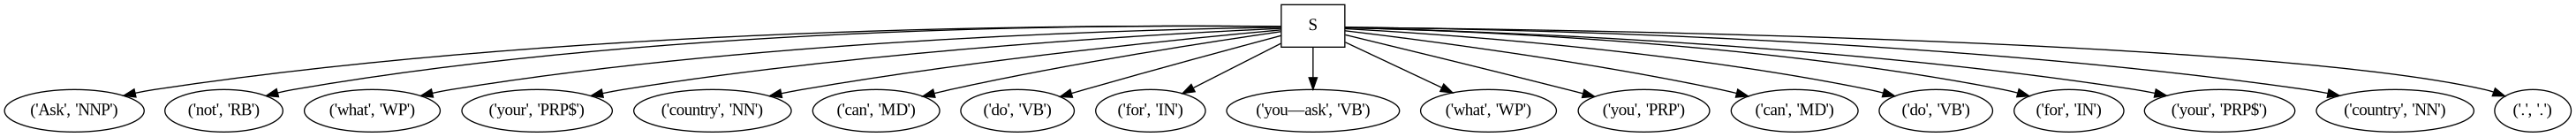

In [19]:
from graphviz import Digraph
from IPython.display import Image, display
import nltk

def draw_nltk_tree_as_image(tree_obj, filename='nltk_tree_output', format='png'):
    """
    NLTK Tree 객체를 Graphviz를 사용하여 이미지로 변환하고 표시합니다.
    """
    dot = Digraph(comment='NLTK Tree', format=format)
    node_id_counter = [0] # 재귀 함수 내에서 ID를 추적하기 위한 카운터

    def add_nodes_edges(sub_tree, parent_id=None):
        current_node_id = str(node_id_counter[0])
        node_id_counter[0] += 1

        # 리프 노드(단어)와 비리프 노드(태그)를 구분하여 레이블 설정
        if isinstance(sub_tree, nltk.tree.Tree):
            label = sub_tree.label()
            dot.node(current_node_id, label, shape='box') # 비리프 노드는 상자로 표시
        else:
            # 리프 노드는 단어와 POS 태그를 모두 포함할 수 있습니다. 예: ('word', 'POS')
            label = str(sub_tree)
            dot.node(current_node_id, label, shape='ellipse') # 리프 노드는 타원으로 표시

        if parent_id is not None:
            dot.edge(parent_id, current_node_id)

        if isinstance(sub_tree, nltk.tree.Tree):
            for child in sub_tree:
                add_nodes_edges(child, current_node_id)

    add_nodes_edges(tree_obj)
    dot.render(filename, view=False, cleanup=True)
    return Image(f'{filename}.{format}')

# 이전 단계에서 생성된 'entities' 객체를 사용하여 시각화
# 'entities'는 nltk.tree.Tree 객체입니다.
if 'entities' in locals():
    print("NER 트리를 시각화합니다...")
    image = draw_nltk_tree_as_image(entities, filename='ner_tree_visualization')
    display(image)
else:
    print("오류: 'entities' 객체를 찾을 수 없습니다. 이전 셀을 실행하여 'entities'를 생성해주세요.")